# VPDS - Final Project - Group A

## Question 1

In [1]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Read and load the dataset
df_raw = pd.read_csv('Youth_DASS_And_TIPI_Dataset_Cleaned_With_Calculated_And_Categorized_Columns.csv')
# Make a copy of the dataset so any modifications won't affect the original dataset
df = df_raw.copy()
df

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,TIPI4_R_Normalized,TIPI6_R_Normalized,TIPI8_R_Normalized,TIPI10_R_Normalized,Extraversion_Normalized,Agreeableness_Normalized,Conscientiousness_Normalized,Emotional_Stability_Normalized,Openness_Normalized,TIPI_Total_Normalized
0,3,3,1,3,3,3,3,3,1,0,...,0.0,0.000000,0.285714,0.857143,0.071429,0.565217,0.642857,0.076923,0.928571,0.59375
1,3,0,1,2,3,3,2,3,2,1,...,0.0,0.500000,0.000000,0.285714,0.642857,0.565217,0.285714,0.076923,0.500000,0.68750
2,2,0,3,0,3,2,0,2,1,3,...,1.0,0.166667,0.285714,0.714286,0.214286,0.391304,0.285714,0.615385,0.714286,0.25000
3,1,1,2,3,3,1,3,3,3,2,...,0.2,0.333333,0.142857,0.571429,0.285714,0.391304,0.285714,0.307692,0.642857,0.43750
4,0,0,1,0,2,0,0,2,2,1,...,1.0,0.000000,0.714286,0.000000,0.142857,0.913043,0.785714,0.923077,0.500000,0.53125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27172,3,3,3,2,3,3,2,2,3,3,...,0.0,0.166667,0.428571,0.142857,0.142857,0.478261,0.571429,0.230769,0.285714,0.53125
27173,2,3,1,1,1,3,3,1,0,2,...,0.4,0.666667,0.714286,0.000000,0.714286,0.391304,0.642857,0.538462,0.428571,0.59375
27174,1,0,2,1,2,1,0,2,0,3,...,0.4,0.333333,0.571429,0.142857,0.285714,0.652174,0.500000,0.384615,0.500000,0.34375
27175,2,3,2,3,2,3,3,3,2,3,...,0.0,0.166667,0.000000,0.428571,0.357143,0.304348,0.357143,0.307692,0.500000,0.65625


In [3]:
# Define features
# Choose predictors (Psychological + Personality + Demographics)
X = df[['Stress_Score', 'Anxiety_Score', 'Emotional_Stability', 'Extraversion',
        'Agreeableness', 'Conscientiousness', 'Openness', 'Age', 'Gender', 'Education',
        'Married', 'Family_Size']]

In [4]:
# Define binary target for MDD
df['MDD_Present'] = df['Depression_Severity'].apply(lambda x: 0 if x in ['Normal', 'Mild'] else 1)
y = df['MDD_Present']

In [5]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=126)

In [6]:
# Print the total counts and shapes of train and test data
print(f"Total dataset size: {len(X)}")
print(f"Training set (Features): {X_train.shape} | Training labels: {y_train.shape}")
print(f"Testing set (Features):  {X_test.shape} | Testing labels:  {y_test.shape}")

Total dataset size: 27177
Training set (Features): (21741, 12) | Training labels: (21741,)
Testing set (Features):  (5436, 12) | Testing labels:  (5436,)


In [7]:
# Data Preparation (Min-Max Normalization)
# Initializing Min-Max scaler to standardize all values strictly to a 0-1 range
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Question 2

In [9]:
# Generate Test Predictions and Soft Probabilities
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

In [10]:
# Evaluate model
print('==============================')
print('The Model Evaluation')
print('==============================')

print('\n------------------------------')
print('The Accuracy Score')
print('------------------------------')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')

true_negatives, false_positives, false_negatives, true_positives = confusion_matrix(y_test, y_pred).ravel()
print('\n------------------------------')
print('Raw Confusion Matrix')
print('------------------------------')
print(f'Confusion Matrix:\n {confusion_matrix(y_test, y_pred)}')

# Print the results of confusion matrix clearly
print('\n------------------------------')
print("Confusion Matrix Breakdown")
print(f"True Negatives  (TN): {true_negatives}")
print(f"False Positives (FP): {false_positives}  <- (Type I Error)")
print(f"False Negatives (FN): {false_negatives}  <- (Type II Error)")
print(f"True Positives  (TP): {true_positives}")
print('------------------------------')

print('\n------------------------------')
print("Visual Layout of Confusion Matrix:")
print('------------------------------')
print(f"[{true_negatives} {false_positives}]")
print(f"[{false_negatives} {true_positives}]")

The Model Evaluation

------------------------------
The Accuracy Score
------------------------------
Accuracy: 0.84

------------------------------
Raw Confusion Matrix
------------------------------
Confusion Matrix:
 [[1047  549]
 [ 333 3507]]

------------------------------
Confusion Matrix Breakdown
True Negatives  (TN): 1047
False Positives (FP): 549  <- (Type I Error)
False Negatives (FN): 333  <- (Type II Error)
True Positives  (TP): 3507
------------------------------

------------------------------
Visual Layout of Confusion Matrix:
------------------------------
[1047 549]
[333 3507]


In [11]:
# Print classification report
print('------------------------------')
print('The Classification Report')
print('------------------------------')
print(classification_report(y_test, y_pred))

------------------------------
The Classification Report
------------------------------
              precision    recall  f1-score   support

           0       0.76      0.66      0.70      1596
           1       0.86      0.91      0.89      3840

    accuracy                           0.84      5436
   macro avg       0.81      0.78      0.80      5436
weighted avg       0.83      0.84      0.83      5436



## Question 3

### Heatmap Generation

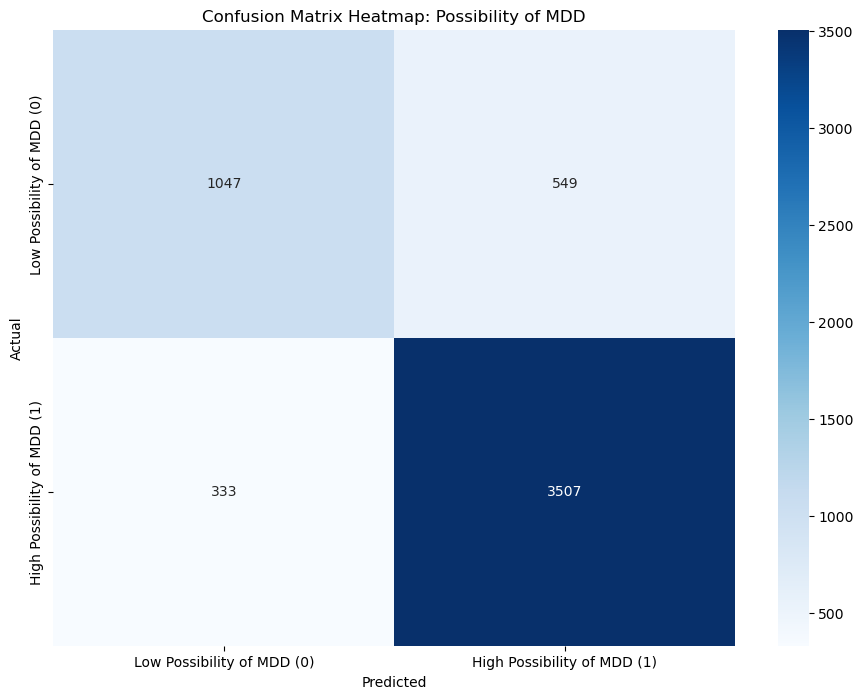

In [12]:
# Heatmap Generation
the_confusion_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(11, 8))
sns.heatmap(the_confusion_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels = ['Low Possibility of MDD (0)', 'High Possibility of MDD (1)'],
            yticklabels = ['Low Possibility of MDD (0)', 'High Possibility of MDD (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap: Possibility of MDD')
plt.savefig('Confusion Matrix Heatmap (Possibility of MDD).png')
plt.show()

### Advanced Data Visualizations

#### Sigmoid Curve 1: Stress Score vs Probability of MDD

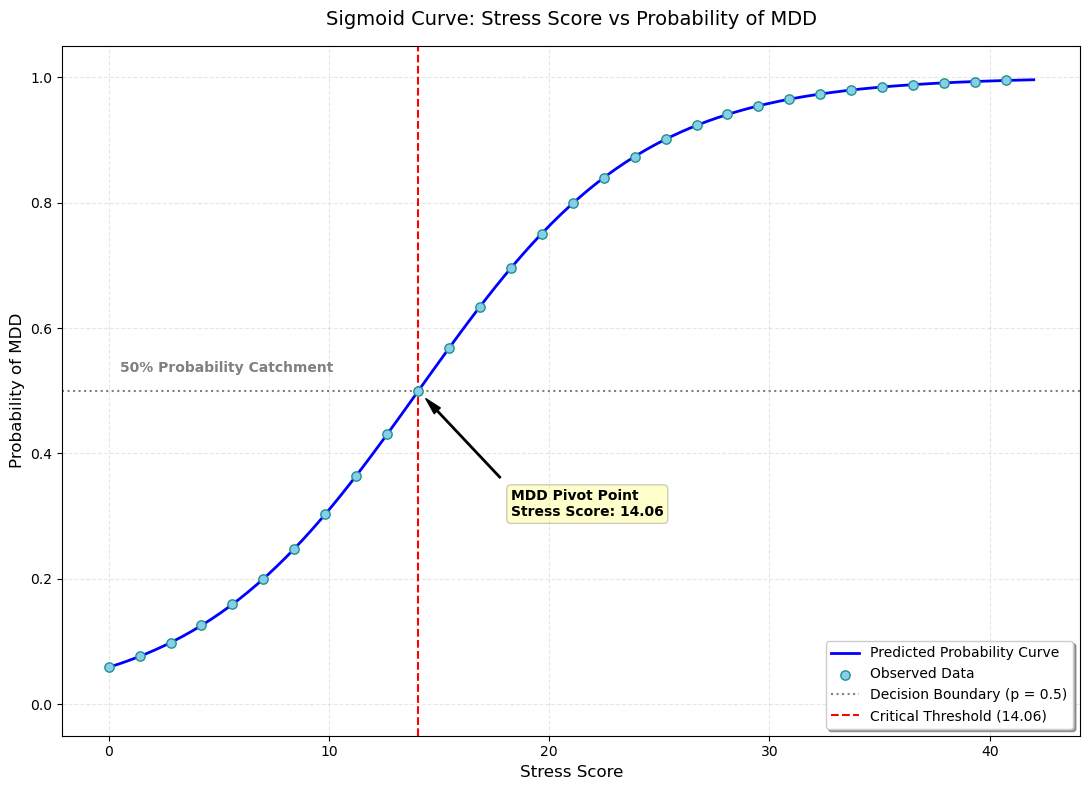

Intercept: -2.7675841396529193
Coefficient: 0.1968017924455587
Stress Threshold: 14.06279945554112


In [13]:
# Model fitting
X_range = np.linspace(X['Stress_Score'].min(), X['Stress_Score'].max(), 300).reshape(-1, 1)
model_single = LogisticRegression(max_iter=1000)
model_single.fit(X[['Stress_Score']], y)

y_prob_curve = model_single.predict_proba(pd.DataFrame(X_range, columns=['Stress_Score']))[:, 1]

# Calculate the 50% threshold
# Formula for logistic regression boundary: intercept + coef * X = 0 -> X = -intercept / coef
intercept = model_single.intercept_[0]
coefficient = model_single.coef_[0][0]
stress_threshold = -intercept / coefficient

# --- Plotting ---
plt.figure(figsize=(11, 8))

# Plot the main S-curve and markers
plt.plot(X_range, y_prob_curve, color='blue', linewidth=2, label='Predicted Probability Curve')
plt.scatter(X_range[::10], y_prob_curve[::10], color='skyblue', edgecolor='#21918c', 
            s=45, label='Observed Data', zorder=4)

# Draw the boundary lines
# Horizontal line at 0.5 probability
plt.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5, label='Decision Boundary (p = 0.5)')

# Vertical line hitting the calculated stress threshold
plt.axvline(x=stress_threshold, color='red', linestyle='--', linewidth=1.5, 
            label=f'Critical Threshold ({stress_threshold:.2f})')

# Add text labels and annotations
plt.text(X['Stress_Score'].min() + 0.5, 0.53, '50% Probability Catchment', 
         color='gray', fontsize=10, weight='semibold')

plt.annotate(f'MDD Pivot Point\nStress Score: {stress_threshold:.2f}',
             xy=(stress_threshold, 0.5),
             xytext=(stress_threshold + (X_range.max() - X_range.min())*0.1, 0.3),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
             fontsize=10, weight='semibold', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.2))

# Aesthetic adjustments
plt.title('Sigmoid Curve: Stress Score vs Probability of MDD', fontsize=14, pad=15)
plt.xlabel('Stress Score', fontsize=12)
plt.ylabel('Probability of MDD', fontsize=12)
plt.ylim(-0.05, 1.05) # Keep padding clean for 0 and 1 probabilities
plt.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.tight_layout()
plt.savefig('Sigmoid Curve - Stress Score vs Probability of MDD.png')
plt.show()
print(f'Intercept: {intercept}')
print(f'Coefficient: {coefficient}')
print(f'Stress Threshold: {stress_threshold}')

#### Sigmoid Curve 2: Anxiety Score vs Probability of MDD

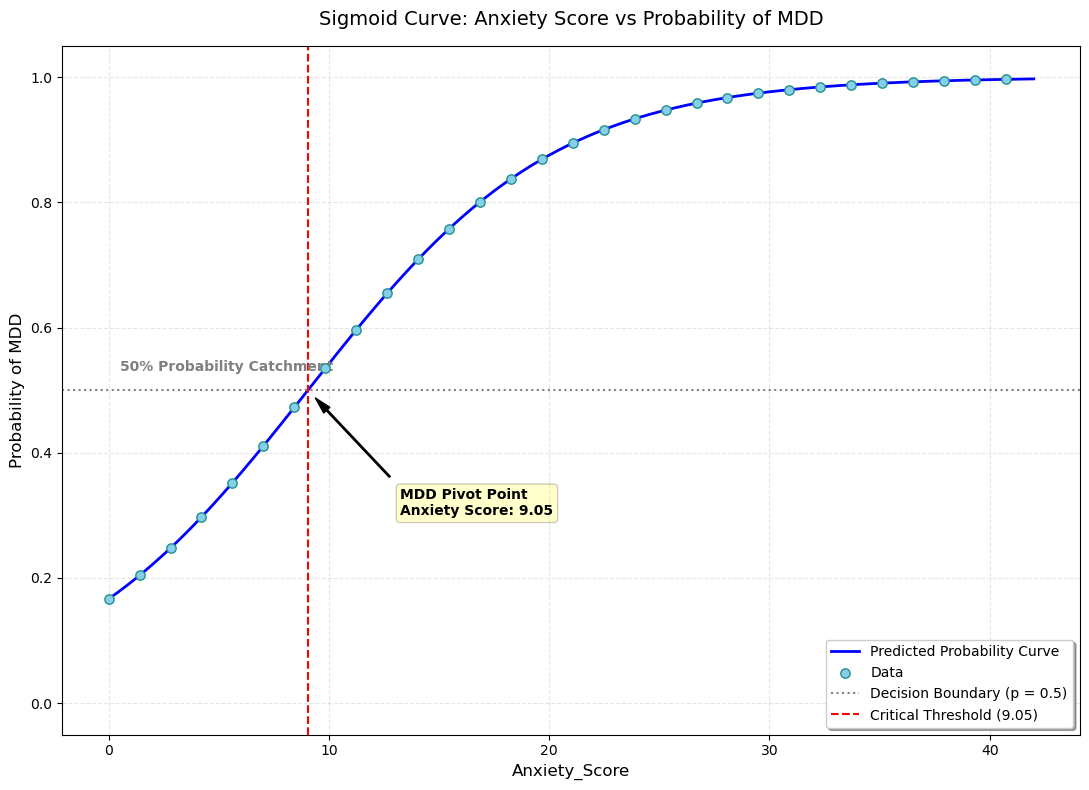

Intercept: -1.6101558619209784
Coefficient: 0.17796218636323977
Anxiety Threshold: 9.047741516472938


In [14]:
# Model fitting
X_range = np.linspace(X['Anxiety_Score'].min(), X['Anxiety_Score'].max(), 300).reshape(-1, 1)
model_single = LogisticRegression(max_iter=1000)
model_single.fit(X[['Anxiety_Score']], y)

y_prob_curve = model_single.predict_proba(pd.DataFrame(X_range, columns=['Anxiety_Score']))[:, 1]

# Calculate the 50% threshold
# Formula for logistic regression boundary: intercept + coef * X = 0 -> X = -intercept / coef
intercept = model_single.intercept_[0]
coefficient = model_single.coef_[0][0]
anxiety_threshold = -intercept / coefficient

# --- Plotting ---
plt.figure(figsize=(11, 8))

# Plot the main S-curve and markers
plt.plot(X_range, y_prob_curve, color='blue', linewidth=2, label='Predicted Probability Curve')
plt.scatter(X_range[::10], y_prob_curve[::10], color='skyblue', edgecolor='#21918c', 
            s=45, label='Data', zorder=4)

# Draw the boundary lines
# Horizontal line at 0.5 probability
plt.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5, label='Decision Boundary (p = 0.5)')

# Vertical line hitting the calculated stress threshold
plt.axvline(x=anxiety_threshold, color='red', linestyle='--', linewidth=1.5, 
            label=f'Critical Threshold ({anxiety_threshold:.2f})')

# Add text labels and annotations
plt.text(X['Anxiety_Score'].min() + 0.5, 0.53, '50% Probability Catchment', 
         color='gray', fontsize=10, weight='semibold')

plt.annotate(f'MDD Pivot Point\nAnxiety Score: {anxiety_threshold:.2f}',
             xy=(anxiety_threshold, 0.5),
             xytext=(anxiety_threshold + (X_range.max() - X_range.min())*0.1, 0.3),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
             fontsize=10, weight='semibold', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.2))

# Aesthetic adjustments
plt.title('Sigmoid Curve: Anxiety Score vs Probability of MDD', fontsize=14, pad=15)
plt.xlabel('Anxiety_Score', fontsize=12)
plt.ylabel('Probability of MDD', fontsize=12)
plt.ylim(-0.05, 1.05) # Keep padding clean for 0 and 1 probabilities
plt.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.savefig('Sigmoid Curve - Anxiety Score vs Probability of MDD.png')
plt.tight_layout()
plt.show()
print(f'Intercept: {intercept}')
print(f'Coefficient: {coefficient}')
print(f'Anxiety Threshold: {anxiety_threshold}')

#### Sigmoid Curve 3: Emotional Stability Score vs Probability of MDD

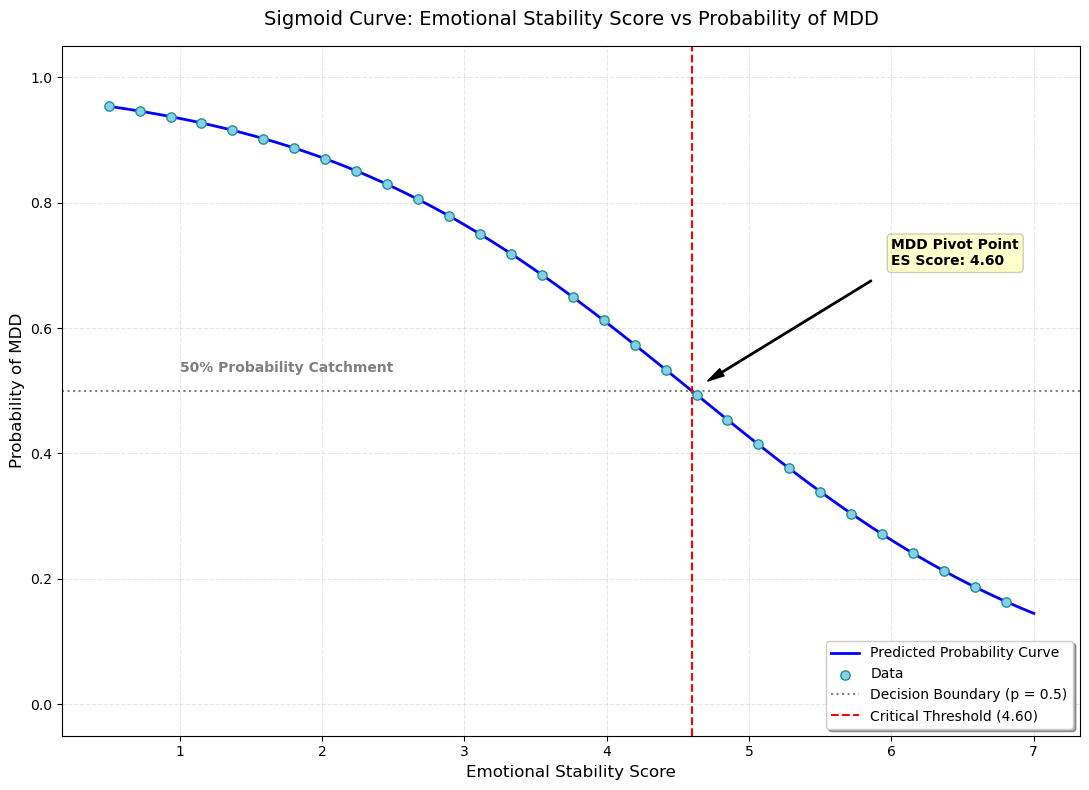

Intercept: 3.392688360624698
Coefficient: -0.7380653195235872
Emotional Stability Threshold: 4.596731848631825


In [15]:
# Model fitting
X_range = np.linspace(X['Emotional_Stability'].min(), X['Emotional_Stability'].max(), 300).reshape(-1, 1)
model_single = LogisticRegression(max_iter=1000)
model_single.fit(X[['Emotional_Stability']], y)

y_prob_curve = model_single.predict_proba(pd.DataFrame(X_range, columns=['Emotional_Stability']))[:, 1]

# Calculate the 50% threshold
# Formula for logistic regression boundary: intercept + coef * X = 0 -> X = -intercept / coef
intercept = model_single.intercept_[0]
coefficient = model_single.coef_[0][0]
emotional_stability_threshold = -intercept / coefficient

# --- Plotting ---
plt.figure(figsize=(11, 8))

# Plot the main S-curve and markers
plt.plot(X_range, y_prob_curve, color='blue', linewidth=2, label='Predicted Probability Curve')
plt.scatter(X_range[::10], y_prob_curve[::10], color='skyblue', edgecolor='#21918c', 
            s=45, label='Data', zorder=4)

# Draw the boundary lines
# Horizontal line at 0.5 probability
plt.axhline(y=0.5, color='gray', linestyle=':', linewidth=1.5, label='Decision Boundary (p = 0.5)')

# Vertical line hitting the calculated stress threshold
plt.axvline(x=emotional_stability_threshold, color='red', linestyle='--', linewidth=1.5, 
            label=f'Critical Threshold ({emotional_stability_threshold:.2f})')

# Add text labels and annotations
plt.text(X['Emotional_Stability'].min() + 0.5, 0.53, '50% Probability Catchment', 
         color='gray', fontsize=10, weight='semibold')

plt.annotate(f'MDD Pivot Point\nES Score: {emotional_stability_threshold:.2f}',
             xy=(emotional_stability_threshold, 0.5),
             xytext=(6.0, 0.7), 
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
             fontsize=10, weight='semibold', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.2))

# Aesthetic adjustments
plt.title('Sigmoid Curve: Emotional Stability Score vs Probability of MDD', fontsize=14, pad=15)
plt.xlabel('Emotional Stability Score', fontsize=12)
plt.ylabel('Probability of MDD', fontsize=12)
plt.ylim(-0.05, 1.05) # Keep padding clean for 0 and 1 probabilities
plt.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.savefig('Sigmoid Curve - Emotional Stability Score vs Probability of MDD.png')
plt.tight_layout()
plt.show()
print(f'Intercept: {intercept}')
print(f'Coefficient: {coefficient}')
print(f'Emotional Stability Threshold: {emotional_stability_threshold}')

#### ROC Curve for MDD Prediction

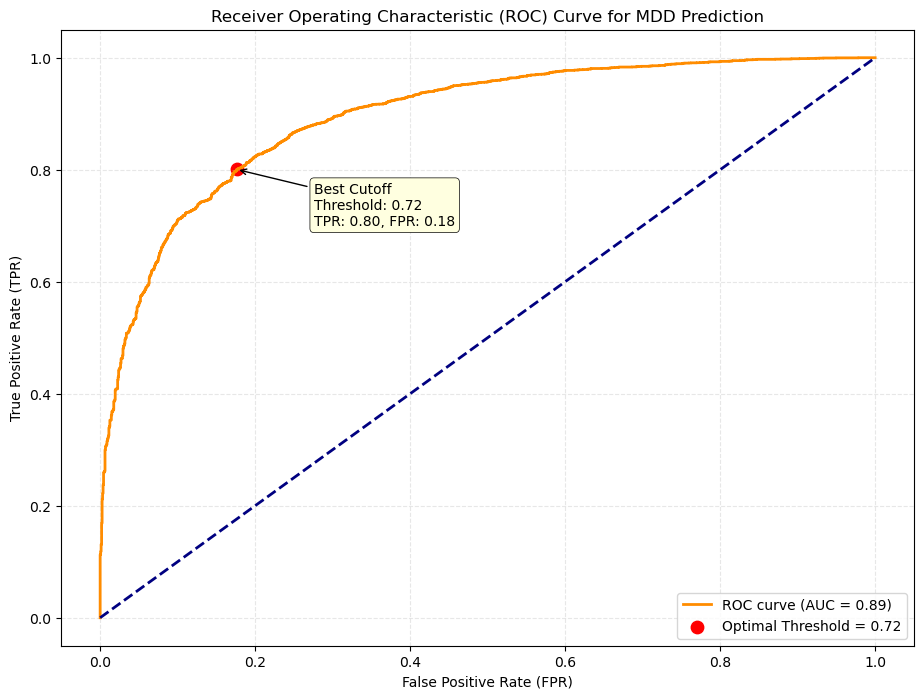

In [16]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(11,8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Highlight optimal threshold (closest to top-left corner)
optimal_idx = np.argmax(tpr - fpr)
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]
optimal_threshold = thresholds[optimal_idx]

plt.scatter(optimal_fpr, optimal_tpr, color='red', s=80, label=f'Optimal Threshold = {optimal_threshold:.2f}')

# Annotate optimal point
plt.annotate(f'Best Cutoff\nThreshold: {optimal_threshold:.2f}\nTPR: {optimal_tpr:.2f}, FPR: {optimal_fpr:.2f}',
             xy=(optimal_fpr, optimal_tpr),
             xytext=(optimal_fpr+0.1, optimal_tpr-0.1),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='black', lw=0.5))

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve for MDD Prediction')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.savefig('ROC Curve for MDD Prediction.png')
plt.show()

#### Scatter Plot 1: Anxiety Score vs Stress Score

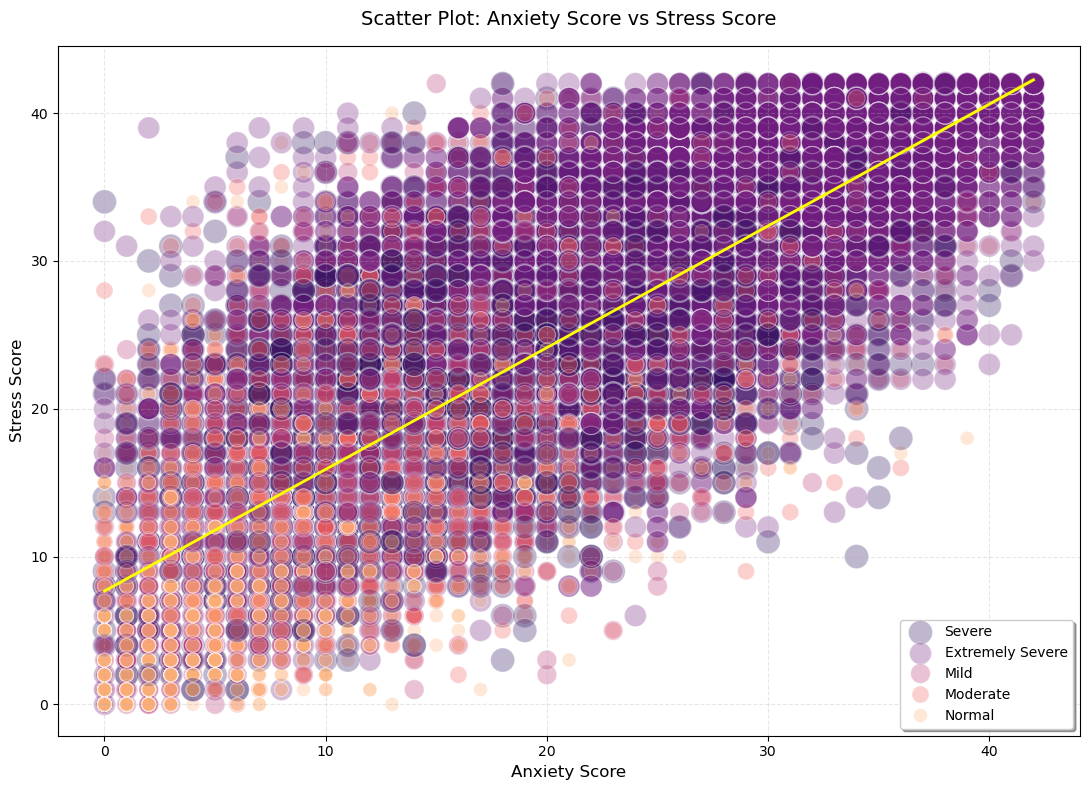

In [17]:
# --- Scatter Plot ---
plt.figure(figsize=(11, 8))

# Plot the bubble scatter plot
sns.scatterplot(data=df, x='Anxiety_Score', y='Stress_Score', size='Depression_Severity', 
                hue='Depression_Severity', palette='magma', sizes=(100, 300), alpha=0.3)

# Plot the regression line
sns.regplot(
    data=df, 
    x='Anxiety_Score', 
    y='Stress_Score', 
    scatter=False,
    line_kws={'color': 'yellow', 'lw': 2}  # Customizes the straight trendline
)

plt.title('Scatter Plot: Anxiety Score vs Stress Score', fontsize=14, pad=15)
plt.xlabel('Anxiety Score', fontsize=12)
plt.ylabel('Stress Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.tight_layout()
plt.savefig('Scatter Plot - Anxiety Score vs Stress Score.png')
plt.show()

#### Scatter Plot 2: Emotional Stability Score vs Overall DASS Score

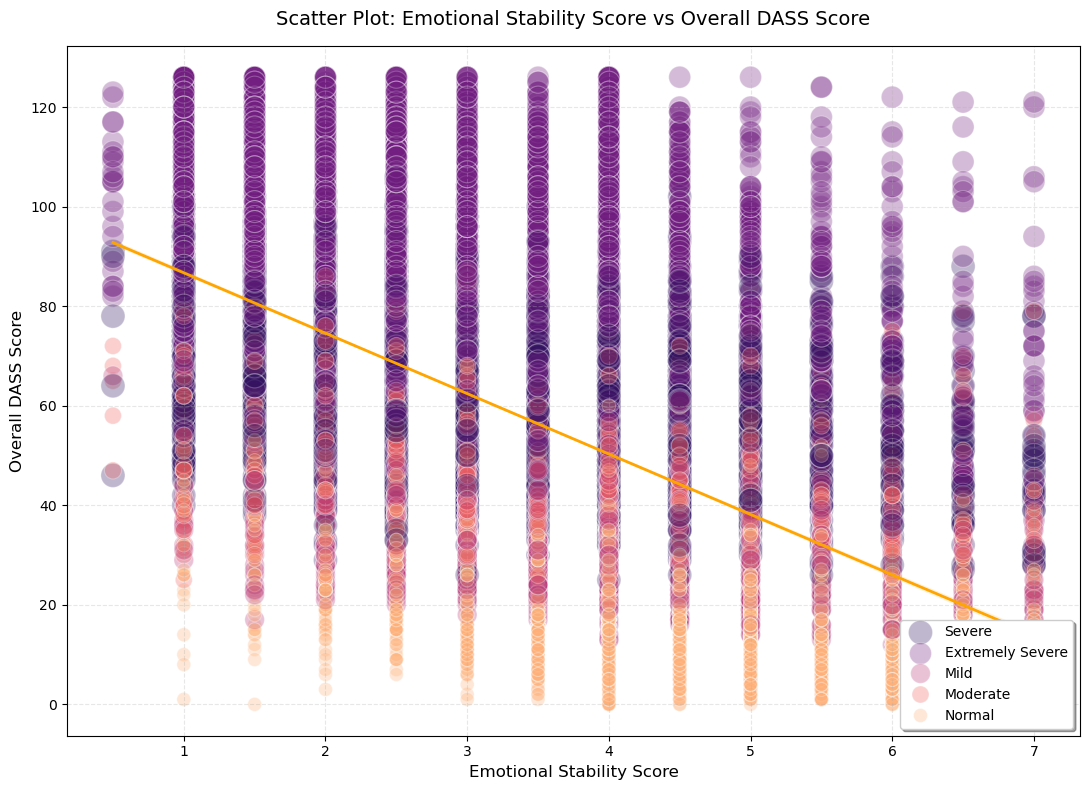

In [18]:
# --- Scatter Plot ---
plt.figure(figsize=(11, 8))

# Plot the bubble scatter plot
sns.scatterplot(data=df, x='Emotional_Stability', y='Overall_Dass', size='Depression_Severity', 
                hue='Depression_Severity', palette='magma', sizes=(100, 300), alpha=0.3)

# Plot the regression line
sns.regplot(
    data=df, 
    x='Emotional_Stability', 
    y='Overall_Dass', 
    scatter=False,
    line_kws={'color': 'orange', 'lw': 2}  # Customizes the straight trendline
)

plt.title('Scatter Plot: Emotional Stability Score vs Overall DASS Score', fontsize=14, pad=15)
plt.xlabel('Emotional Stability Score', fontsize=12)
plt.ylabel('Overall DASS Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.tight_layout()
plt.savefig('Scatter Plot - Emotional Stability Score vs Overall DASS Score.png')
plt.show()

#### Scatter Plot 3: Emotional Stability Score vs Stress Score

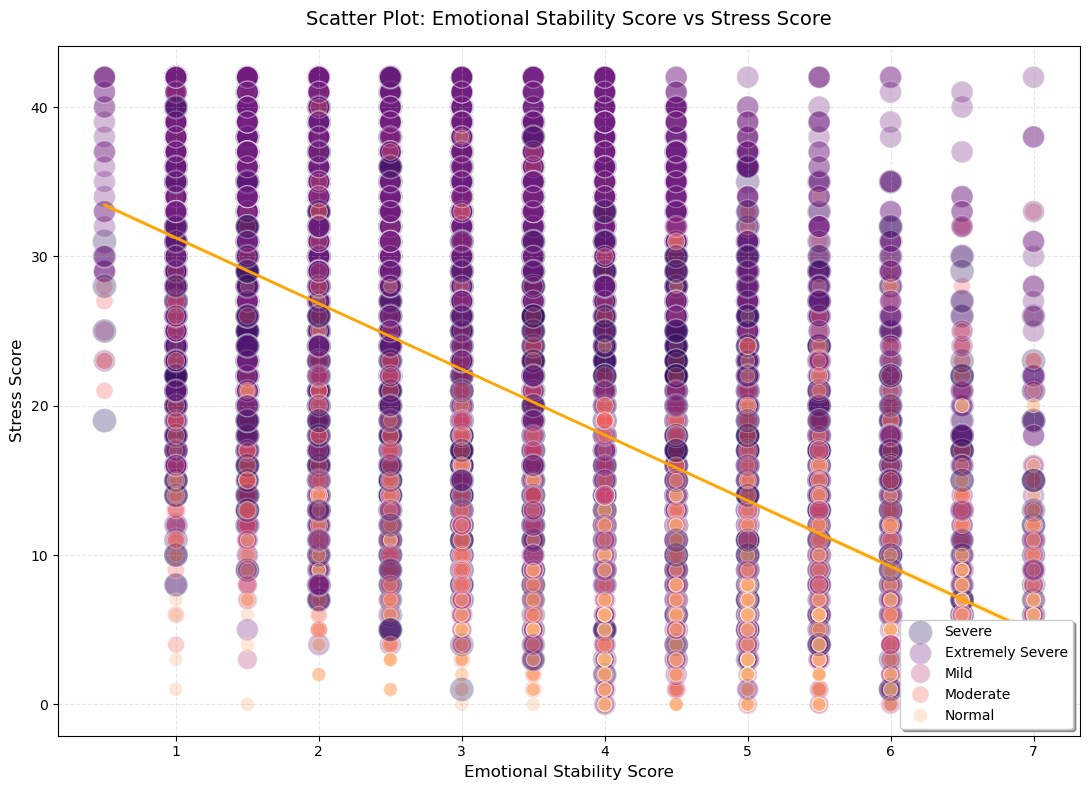

In [19]:
# --- Scatter Plot ---
plt.figure(figsize=(11, 8))

# Plot the bubble scatter plot
sns.scatterplot(data=df, x='Emotional_Stability', y='Stress_Score', size='Depression_Severity', 
                hue='Depression_Severity', palette='magma', sizes=(100, 300), alpha=0.3)

# Plot the regression line
sns.regplot(
    data=df, 
    x='Emotional_Stability', 
    y='Stress_Score', 
    scatter=False,
    line_kws={'color': 'orange', 'lw': 2}  # Customizes the straight trendline
)

plt.title('Scatter Plot: Emotional Stability Score vs Stress Score', fontsize=14, pad=15)
plt.xlabel('Emotional Stability Score', fontsize=12)
plt.ylabel('Stress Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, zorder=1)
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.tight_layout()
plt.savefig('Scatter Plot - Emotional Stability Score vs Stress Score.png')
plt.show()

## Question 4

### Dashboard

In [20]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

severity_order = ["Normal", "Mild", "Moderate", "Severe", "Extremely Severe"]
severity_counts = df["Depression_Severity"].value_counts().reindex(severity_order).fillna(0)

total_records = len(df)
normal_count = severity_counts["Normal"]
mild_count = severity_counts["Mild"]
moderate_count = severity_counts["Moderate"]
severe_count = severity_counts["Severe"]
extreme_count = severity_counts["Extremely Severe"]

low_risk = normal_count + mild_count
high_risk = moderate_count + severe_count + extreme_count

risk_labels = ["Low Risk", "High Risk"]
risk_values = [low_risk, high_risk]

anxiety_counts = df["Anxiety_Severity"].value_counts() if "Anxiety_Severity" in df.columns else severity_counts
age_counts = df["Age"].value_counts().sort_index()

personality_cols = ["Extraversion", "Agreeableness", "Conscientiousness", "Emotional_Stability", "Openness"]
personality_avg = df[personality_cols].mean()

age_group = df.groupby("Age")[["Stress_Score", "Anxiety_Score", "Depression_Score"]].mean().sort_index()

age_severity = pd.crosstab(df["Age"], df["Depression_Severity"])
age_severity = age_severity.reindex(columns=severity_order).fillna(0)

fig = make_subplots(
    rows=4,
    cols=6,
    specs=[
        [{"type": "pie", "colspan": 2}, None, {"type": "pie", "colspan": 2}, None, {"type": "pie", "colspan": 2}, None],
        [{"type": "bar", "colspan": 2}, None, {"type": "bar", "colspan": 2}, None, {"type": "bar", "colspan": 2}, None],
        [{"type": "scatter", "colspan": 3}, None, None, {"type": "scatter", "colspan": 3}, None, None],
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]
    ],
    subplot_titles=(
        "Depression Severity Share",
        "Risk Category Share",
        "Anxiety Severity Share",
        "Depression Severity Count",
        "Age Distribution",
        "Average Personality Traits",
        "Stacked Area DASS Score by Age",
        "Stacked Area Severity by Age",
        "Total",
        "Normal",
        "Mild",
        "Moderate",
        "Severe",
        "Extreme"
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.08
)

# PIE CHARTS
fig.add_trace(go.Pie(
    labels=severity_counts.index,
    values=severity_counts.values,
    hole=0.55,
    textinfo="percent",
    textfont_size=9,
    showlegend=False
), row=1, col=1)

fig.add_trace(go.Pie(
    labels=risk_labels,
    values=risk_values,
    hole=0.55,
    textinfo="percent",
    textfont_size=9,
    showlegend=False
), row=1, col=3)

fig.add_trace(go.Pie(
    labels=anxiety_counts.index,
    values=anxiety_counts.values,
    hole=0.55,
    textinfo="percent",
    textfont_size=9,
    showlegend=False
), row=1, col=5)

# BAR 1
fig.add_trace(go.Bar(
    x=severity_order,
    y=severity_counts.values,
    marker_color=["#2ECC71", "#F9D65C", "#F39C12", "#E74C3C", "#8E44AD"],
    text=[f"{int(v):,}" for v in severity_counts.values],
    textposition="outside",
    textfont=dict(size=10),
    cliponaxis=False,
    showlegend=False
), row=2, col=1)

# BAR 2
fig.add_trace(go.Bar(
    x=age_counts.index,
    y=age_counts.values,
    marker_color="#4CC9F0",
    text=[f"{int(v):,}" for v in age_counts.values],
    textposition="outside",
    textfont=dict(size=8),
    cliponaxis=False,
    showlegend=False
), row=2, col=3)

# BAR 3
fig.add_trace(go.Bar(
    x=["Extra", "Agree", "Conscious", "Emotion", "Open"],
    y=personality_avg.values,
    marker_color="#7209B7",
    text=[f"{v:.2f}" for v in personality_avg.values],
    textposition="outside",
    textfont=dict(size=9),
    cliponaxis=False,
    showlegend=False
), row=2, col=5)

# STACKED AREA 1
fig.add_trace(go.Scatter(
    x=age_group.index,
    y=age_group["Stress_Score"],
    mode="lines",
    stackgroup="one",
    name="Stress",
    fillcolor="rgba(0,180,216,0.65)",
    line=dict(width=0.5),
    showlegend=False
), row=3, col=1)

fig.add_trace(go.Scatter(
    x=age_group.index,
    y=age_group["Anxiety_Score"],
    mode="lines",
    stackgroup="one",
    name="Anxiety",
    fillcolor="rgba(255,107,107,0.65)",
    line=dict(width=0.5),
    showlegend=False
), row=3, col=1)

fig.add_trace(go.Scatter(
    x=age_group.index,
    y=age_group["Depression_Score"],
    mode="lines",
    stackgroup="one",
    name="Depression",
    fillcolor="rgba(155,93,229,0.65)",
    line=dict(width=0.5),
    showlegend=False
), row=3, col=1)

# STACKED AREA 2
colors = {
    "Normal": "rgba(46,204,113,0.65)",
    "Mild": "rgba(249,214,92,0.65)",
    "Moderate": "rgba(243,156,18,0.65)",
    "Severe": "rgba(231,76,60,0.65)",
    "Extremely Severe": "rgba(142,68,173,0.65)"
}

for severity in severity_order:
    fig.add_trace(go.Scatter(
        x=age_severity.index,
        y=age_severity[severity],
        mode="lines",
        stackgroup="two",
        name=severity,
        fillcolor=colors[severity],
        line=dict(width=0.5),
        showlegend=False
    ), row=3, col=4)

# DASHBOARD SUMMARY
summary_values = [total_records, normal_count, mild_count, moderate_count, severe_count, extreme_count]
summary_titles = ["Total Records", "Normal", "Mild", "Moderate", "Severe", "Extreme"]

for i, (title, value) in enumerate(zip(summary_titles, summary_values), start=1):
    fig.add_trace(go.Indicator(
        mode="number",
        value=value,
        number={"font": {"size": 24}},
        title={"text": title, "font": {"size": 10}}
    ), row=4, col=i)

# CLEAN LEGENDS - placed below/side of each chart
fig.add_annotation(
    text="<span style='color:#2ECC71'>■</span> Normal&nbsp;&nbsp;"
         "<span style='color:#F9D65C'>■</span> Mild&nbsp;&nbsp;"
         "<span style='color:#F39C12'>■</span> Moderate&nbsp;&nbsp;"
         "<span style='color:#E74C3C'>■</span> Severe&nbsp;&nbsp;"
         "<span style='color:#8E44AD'>■</span> Extreme",
    x=0.16, y=0.82, xref="paper", yref="paper",
    showarrow=False, font=dict(size=7)
)

fig.add_annotation(
    text="<span style='color:#FF4D6D'>■</span> Low Risk&nbsp;&nbsp;"
         "<span style='color:#00B4D8'>■</span> High Risk",
    x=0.50, y=0.82, xref="paper", yref="paper",
    showarrow=False, font=dict(size=7)
)

fig.add_annotation(
    text="<span style='color:#2ECC71'>■</span> Normal&nbsp;&nbsp;"
         "<span style='color:#F9D65C'>■</span> Mild&nbsp;&nbsp;"
         "<span style='color:#F39C12'>■</span> Moderate&nbsp;&nbsp;"
         "<span style='color:#E74C3C'>■</span> Severe&nbsp;&nbsp;"
         "<span style='color:#8E44AD'>■</span> Extreme",
    x=0.84, y=0.82, xref="paper", yref="paper",
    showarrow=False, font=dict(size=7)
)

fig.add_annotation(
    text="<span style='color:#2ECC71'>■</span> Normal&nbsp;&nbsp;"
         "<span style='color:#F9D65C'>■</span> Mild&nbsp;&nbsp;"
         "<span style='color:#F39C12'>■</span> Moderate&nbsp;&nbsp;"
         "<span style='color:#E74C3C'>■</span> Severe&nbsp;&nbsp;"
         "<span style='color:#8E44AD'>■</span> Extreme",
    x=0.16, y=0.48, xref="paper", yref="paper",
    showarrow=False, font=dict(size=7)
)

fig.add_annotation(
    text="<span style='color:#4CC9F0'>■</span> Age Distribution",
    x=0.50, y=0.48, xref="paper", yref="paper",
    showarrow=False, font=dict(size=7)
)

fig.add_annotation(
    text="<span style='color:#7209B7'>■</span> Personality Traits",
    x=0.84, y=0.48, xref="paper", yref="paper",
    showarrow=False, font=dict(size=7)
)

fig.add_annotation(
    text="<span style='color:#00B4D8'>■</span> Stress&nbsp;&nbsp;"
         "<span style='color:#FF6B6B'>■</span> Anxiety&nbsp;&nbsp;"
         "<span style='color:#9D4EDD'>■</span> Depression",
    x=0.25, y=0.20, xref="paper", yref="paper",
    showarrow=False, font=dict(size=7)
)

fig.add_annotation(
    text="<span style='color:#2ECC71'>■</span> Normal&nbsp;&nbsp;"
         "<span style='color:#F9D65C'>■</span> Mild&nbsp;&nbsp;"
         "<span style='color:#F39C12'>■</span> Moderate&nbsp;&nbsp;"
         "<span style='color:#E74C3C'>■</span> Severe&nbsp;&nbsp;"
         "<span style='color:#8E44AD'>■</span> Extreme",
    x=0.75, y=0.20, xref="paper", yref="paper",
    showarrow=False, font=dict(size=7)
)


fig.update_layout(
    title={"text": "Dashboard of Major Depressive Disorder (MDD) Among Youth", "x": 0.5, "font": {"size": 18}},
    height=980,
    width=1400,
    template="plotly_white",
    showlegend=False,
    margin=dict(l=30, r=30, t=80, b=60)
)

fig.update_annotations(font_size=8)
fig.update_xaxes(tickfont=dict(size=7), tickangle=-15)
fig.update_yaxes(tickfont=dict(size=7))